# Notebook 10: Comparative Review Before the Validation Redesign

This notebook consolidates the main results from the early holdout-validation phase and places them side by side. Its role in the current series is to close the first major experimentation phase before Notebook 11 strengthens the evaluation method and the later supporting notebooks revisit validation design more explicitly.

The printed experiment labels inside the code cell still follow the original run names so that they remain consistent with earlier saved outputs.

10_experiment_comparison: historical experiment review and comparison 



1. Load historical experiment models... 
✓ Historical models loaded successfully 

2. Prepare validation data(using a fixed split, for review only)... 

Prepare exp05 data(without feature engineering)... 
exp05feature count: 42 

Prepare exp07/08 data(with feature engineering)... 
exp07/08feature count: 45 
Validation setsize: (140000, 45) 

3. Evaluate historical models... 

Evaluate exp05 (XGBoost 500 trees, depth=6)... 
  AUC: 0.7264

Evaluate exp07 (XGBoost + feature selection)... 
  AUC: 0.7251

Evaluate exp08 (LightGBM)... 
  AUC: 0.7248

Evaluate exp09 (simple ensemble): AUC = 0.7256 

4. Historical experiment comparison 
Experiment name AUC Note 
exp05 (500 trees)         0.7264     
exp07 (feat selection)    0.7251     
exp08 (LightGBM)          0.7248     
exp09 (ensemble)          0.7256     
----------------------------------------------------------------------

Best historical experiment: exp05 (500 

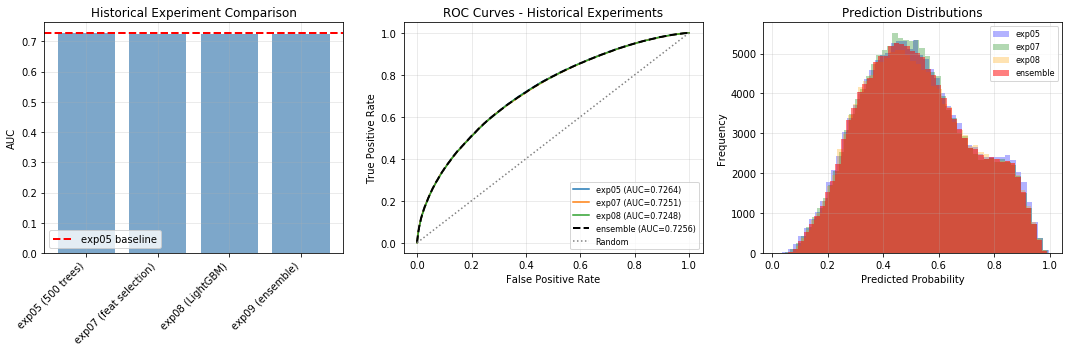


Historical experiment summary 

Experiment timeline review: 
- exp03: default XGBoost parameters -> AUC 0.7192 
- exp04: +300 trees + class weights -> AUC 0.7255 
- exp05:  +500 trees + depth tuning -> AUC 0.7264 (best historical result) 
- exp06: +Feature engineering -> AUC 0.7251 (Feature engineering contributed, but the original features were incorrectly replaced) 
- exp07: +Feature selection (incorrectly removed the original features) -> AUC 0.7251 
- exp08: LightGBM → AUC 0.7248
- exp09: simple ensemble -> AUC 0.7256 

Key findings: 
1. All experiments used the same fixed validation set, which may have led to overfitting. 
2. Experiment 07 incorrectly replaced the original features with interaction features, causing information loss. 
3. Feature engineering was effective, but the original features should have been retained. 
4. Model ensembling produced only a small improvement. 

⚠️ Limitations: 
- This notebook is for review only and is not used for final model selection 
- Ple

In [ ]:
# 10_experiment_comparison.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import joblib
import lightgbm as lgb

print("="*60)
print("10_experiment_comparison: historical experiment review and comparison") 
print("="*60)
print("\nWarning: This notebook is for historical review only and is not used for final model selection") 
print("Warning: Please refer to 11_xgboost_cv_final.ipynb or run python -m src.train_xgb_cv\n") 

# 1. Load historical experiment models(for review only)
print("\n1. Load historical experiment models...") 

models = {
    'exp05_xgboost_500trees': joblib.load('../models/05_xgboost_test_2_depth6.pkl'),
    'exp07_xgboost_feat_sel': joblib.load('../models/07_xgboost_test_4_lr0.1.pkl'),
    'exp08_lightgbm': lgb.Booster(model_file='../models/08_lightgbm_test_1.txt')
}
print("✓ Historical models loaded successfully") 

# 2. Prepare validation data(using the same split as the historical experiments)
print("\n2. Prepare validation data(using a fixed split, for review only)...") 
train = pd.read_csv('../data/train.csv')

# Feature engineering function(for exp07 and exp08)
def create_selected_features(df):
    df_new = df.copy()
    df_new['age_family_history'] = df['age'] * df['family_history_diabetes']
    df_new['age_bmi'] = df['age'] * df['bmi']
    df_new['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    df_new['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df_new['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    return df_new

# Features used by exp05(no feature engineering)
print("\nPrepare exp05 data(without feature engineering)...") 
X_05 = train.drop(['id', 'diagnosed_diabetes'], axis=1)
categorical_cols = ['gender', 'ethnicity', 'education_level',
                   'income_level', 'smoking_status', 'employment_status']
X_05_encoded = pd.get_dummies(X_05, columns=categorical_cols)
print(f"exp05feature count: {X_05_encoded.shape[1]}") 

# Features used by exp07/08(with feature engineering)
print("\nPrepare exp07/08 data(with feature engineering)...") 
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']
X_fe = create_selected_features(X)

features_to_keep = [
    'age_family_history', 'age_bmi', 'cardio_risk_score',
    'cholesterol_ratio', 'non_hdl_cholesterol',
    'physical_activity_minutes_per_week', 'triglycerides', 'bmi',
    'ldl_cholesterol', 'cardiovascular_history', 'diet_score',
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'hdl_cholesterol',
    'cholesterol_total', 'waist_to_hip_ratio', 'sleep_hours_per_day',
    'screen_time_hours_per_day', 'alcohol_consumption_per_week',
    'hypertension_history', 'gender', 'ethnicity', 'education_level',
    'income_level', 'smoking_status', 'employment_status'
]

X_selected = X_fe[features_to_keep]
X_encoded = pd.get_dummies(X_selected, columns=categorical_cols)
print(f"exp07/08feature count: {X_encoded.shape[1]}") 

# Use the same fixed split as the historical experiments
from sklearn.model_selection import train_test_split

X_train_05, X_val_05, y_train_05, y_val_05 = train_test_split(
    X_05_encoded, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

X_val_np = X_val.values.astype('float32')
print(f"Validation setsize: {X_val.shape}") 

# 3. Evaluate historical models
print("\n3. Evaluate historical models...") 

results = {}

print("\nEvaluate exp05 (XGBoost 500 trees, depth=6)...") 
pred_05 = models['exp05_xgboost_500trees'].predict_proba(X_val_05)[:, 1]
auc_05 = roc_auc_score(y_val_05, pred_05)
results['exp05 (500 trees)'] = auc_05
print(f"  AUC: {auc_05:.4f}")

print("\nEvaluate exp07 (XGBoost + feature selection)...") 
pred_07 = models['exp07_xgboost_feat_sel'].predict_proba(X_val)[:, 1]
auc_07 = roc_auc_score(y_val, pred_07)
results['exp07 (feat selection)'] = auc_07
print(f"  AUC: {auc_07:.4f}")

print("\nEvaluate exp08 (LightGBM)...") 
pred_08 = models['exp08_lightgbm'].predict(X_val_np)
auc_08 = roc_auc_score(y_val, pred_08)
results['exp08 (LightGBM)'] = auc_08
print(f"  AUC: {auc_08:.4f}")

ensemble_pred = (pred_07 + pred_08) / 2
ensemble_auc = roc_auc_score(y_val, ensemble_pred)
results['exp09 (ensemble)'] = ensemble_auc
print(f"\nEvaluate exp09 (simple ensemble): AUC = {ensemble_auc:.4f}") 

# 4. Historical experiment comparison
print("\n4. Historical experiment comparison") 
print("="*70)
print(f"{'Experiment name':<25} {'AUC':<10} {'Note':<30}") 
print("="*70)

for name, auc in results.items():
    print(f"{name:<25} {auc:<10.4f} {''}")

print("-"*70)
print(f"\nBest historical experiment: {max(results, key=results.get)} (AUC={max(results.values()):.4f})") 
print("\nWarning: Note: The results above are based on a fixed validation split and may be overfitted") 
print("⚠️ For final model evaluation, please refer to 11_xgboost_cv_final.ipynb(using 5-fold cross-validation)") 

# 5. Visualization comparison
print("\n5. Generate visualization comparison...") 

plt.figure(figsize=(15, 5))

# AUC comparison
plt.subplot(1, 3, 1)
models_list = list(results.keys())
aucs_list = list(results.values())
bars = plt.bar(models_list, aucs_list, color='steelblue', alpha=0.7)
plt.axhline(y=0.7264, color='red', linestyle='--', linewidth=2, label='exp05 baseline')
plt.ylabel('AUC')
plt.title('Historical Experiment Comparison')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# ROC curve comparison - FixKeyError
plt.subplot(1, 3, 2)

roc_data = [
    ('exp05', pred_05, y_val_05, auc_05),
    ('exp07', pred_07, y_val, auc_07),
    ('exp08', pred_08, y_val, auc_08)
]

for name, pred, y_true, auc in roc_data:
    fpr, tpr, _ = roc_curve(y_true, pred)
    plt.plot(fpr, tpr, linewidth=1.5, label=f'{name} (AUC={auc:.4f})')

fpr_ens, tpr_ens, _ = roc_curve(y_val, ensemble_pred)
plt.plot(fpr_ens, tpr_ens, 'k--', linewidth=2, label=f'ensemble (AUC={ensemble_auc:.4f})')
plt.plot([0, 1], [0, 1], 'gray', linestyle=':', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Historical Experiments')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)

# Prediction distribution comparison
plt.subplot(1, 3, 3)
plt.hist(pred_05, bins=50, alpha=0.3, label='exp05', color='blue')
plt.hist(pred_07, bins=50, alpha=0.3, label='exp07', color='green')
plt.hist(pred_08, bins=50, alpha=0.3, label='exp08', color='orange')
plt.hist(ensemble_pred, bins=50, alpha=0.5, color='red', label='ensemble')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Prediction Distributions')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/10_experiment_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# 6. Historical experiment summary
print("\n" + "="*60)
print("Historical experiment summary") 
print("="*60)
print("""
Experiment timeline review:

- exp03: default XGBoost parameters -> AUC 0.7192
- exp04: +300 trees + class weights -> AUC 0.7255
- exp05: +500 trees + depth tuning -> AUC 0.7264 (best historical performance)
- exp06: +Feature engineering -> AUC 0.7251 (Feature engineering contributed but was incorrectly replaced)
- exp07: +Feature selection (original features were incorrectly deleted) -> AUC 0.7251
- exp08: LightGBM → AUC 0.7248
- exp09: Simple ensemble -> AUC 0.7256

Key findings:

1. All experiments used the same fixed validation set, which may lead to overfitting.
2. exp07 incorrectly replaced original features with interactive features, resulting in information loss. 
3. Feature engineering is effective, but original features should be preserved.
4. Model ensemble shows a slight improvement.

⚠️ Limitations: 
- This notebook is for review only and is not used for final model selection 
- Please use 11_xgboost_cv_final.ipynb (5-fold cross-validation) 
- Final results: CV AUC = 0.7256 ± 0.0008, OOF AUC = 0.7256 
""")
